In [2]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

c:\Users\paliw\OneDrive\Documents\Self_study_skill\LangGraph\LG_CampusX\ven2\Lib\site-packages\langchain_core\_api\deprecation.py:25: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1


In [18]:
class BMI_set(TypedDict): #This is our state

    weight_kg: float
    Height_m: float
    bmi: float
    category: str  #best practise

In [19]:
def calc_bmi(state: BMI_set) -> BMI_set:
    weight = state['weight_kg']
    height = state['Height_m']


    bmi = weight/(height**2)

    state['bmi'] = round(bmi, 2)

    return state

Not the best Practise -----

In [14]:
def label_weit(state: BMI_set):
    bmi = state['bmi']
    if bmi < 17:
        Some = "Under weight"
    elif bmi >= 17 and bmi <=25:
        Some = "Fit"
    else:
        Some = "Over-Weight"

    print(Some)

--------------

Best practise----------

In [20]:
def label(state: BMI_set) -> BMI_set:
    bmi = state['bmi']
    if bmi < 17:
        state['category'] = "Under weight"
    elif bmi >= 17 and bmi <=25:
        state['category'] = "Fit"
    else:
        state['category'] = "Over-Weight"

    return state

--------------------

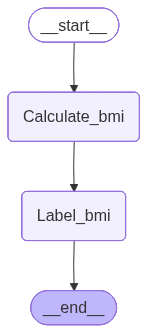

In [26]:
graph = StateGraph(BMI_set) #defining graph

#Add nodes
graph.add_node('Calculate_bmi',calc_bmi) #add_node is adding node, (name of node, Python function that we have to write)
graph.add_node('Label_bmi',label)

#Add edges
graph.add_edge(START, 'Calculate_bmi')
graph.add_edge('Calculate_bmi','Label_bmi')
graph.add_edge('Label_bmi', END)
#compile the graph

workflow = graph.compile()

graph.compile()

In [23]:
#execute the graph

workflow.invoke({'weight_kg':80,'Height_m':1.73})

{'weight_kg': 80, 'Height_m': 1.73, 'bmi': 26.73, 'category': 'Over-Weight'}

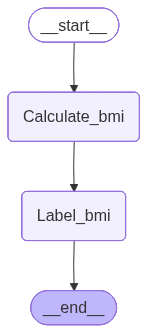

In [24]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())